In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import itertools

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

In [2]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

In [3]:
from true_graph import TrueGraph
from learner import FactorGraphLearner, learner_to_graph
from noise_generator import IndependentMarginals
from metrics import *
from random_graph import generate_random_graph, generate_random_tree
from chow_liu import chow_liu

# Graphs and Samples

In [4]:
rng = np.random.default_rng(seed=311)
random_graph = generate_random_graph(n=10, alphabet_size=2, n_factors=8, rng=rng)

rng = np.random.default_rng(seed=24)
random_tree = generate_random_tree(n=10, alphabet_size=2, rng=rng)

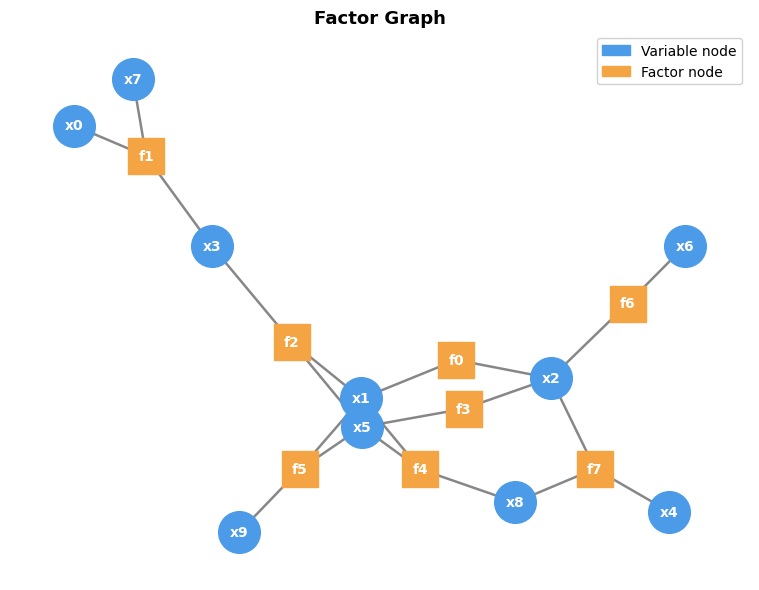

In [5]:
random_graph.display_graph(seed=388)
plt.show()

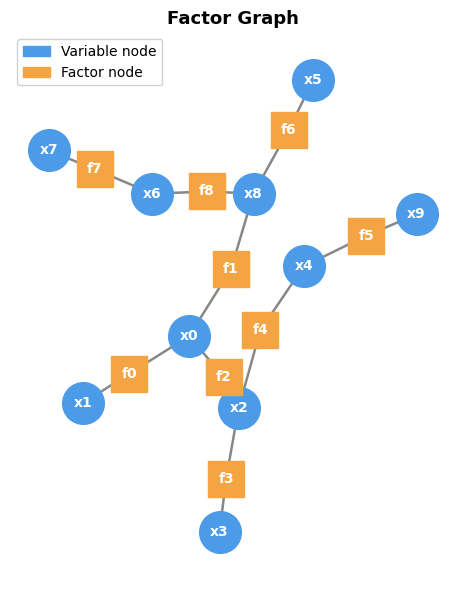

In [6]:
random_tree.display_graph(seed=72)
plt.show()

In [7]:
samples_graph = random_graph.sample(nsamples=500, seed=689)
samples_tree = random_tree.sample(nsamples=500, seed=920)

100%|████████████████████████████████████████| 500/500 [00:01<00:00, 366.20it/s]


# Experiment

In [8]:
def one_learner(graph, samples, K, hidden_dims=(16,16), max_factor_size=5,
                shared_mlp=False, epochs=100, lr=0.01,
                l_mask=0.0, l_weight=0.0, l_mlp=0.01, l_bp=0.001,
                schedule=True, seed=123, verbose=True):

    alph_size = graph.alphabet_sizes[0]
    n_vars = graph.n

    ng = IndependentMarginals(samples, alphabet_size=alph_size, alpha=1, seed=456)

    learner = FactorGraphLearner(
        n_vars=n_vars,
        alphabet_size=alph_size,
        K=K,
        noise_generator=ng,
        hidden_dims=hidden_dims,
        max_factor_size=max_factor_size,
        shared_mlp=shared_mlp,
        seed=seed
    )

    losses, diagnostics = learner.train(
        samples,
        n_epochs=epochs,
        lr=lr,
        lambda_mask=l_mask,
        lambda_weight=l_weight,
        lambda_mlp_l2=l_mlp,
        lambda_bp=l_bp,
        penalty_schedule=schedule,
        verbose=verbose
    )

    return learner, losses, diagnostics

In [9]:
def run_experiment(graph, samples, lambda_bp_vals, n_runs=1, K=None,
                   hidden_dims=(16,16), max_factor_size=5,
                   shared_mlp=False, epochs=100, lr=0.01,
                   l_mask=0.0, l_weight=0.0, l_mlp=0.01,
                   schedule=True, seed=123, verbose=False, compute_kl=True):
    if K is None:
        K = samples.shape[1]

    results = []
    rng = np.random.default_rng(seed)

    with tqdm(total=len(lambda_bp_vals)*n_runs) as pbar:
        for l_bp in lambda_bp_vals:
            r = {
                "lambda_bp": l_bp,
                "nce_loss": 0,
                "reg_loss": 0,
                "total_loss": 0,
                "n_active_factors": 0,
                "avg_factor_size": 0,
                "density": 0,
                "SHD": 0,
                "KL": 0 if compute_kl else None,
                "learners": [] 
            }
            lrn_seeds = rng.integers(0,1000,size=n_runs)
            for i in range(n_runs):
                learner, losses, dgs = one_learner(
                    graph, samples, K,
                    hidden_dims=hidden_dims,
                    max_factor_size=max_factor_size,
                    shared_mlp=shared_mlp,
                    epochs=epochs,
                    lr=lr,
                    l_mask=l_mask,
                    l_weight=l_weight,
                    l_mlp=l_mlp,
                    l_bp=l_bp,
                    schedule=schedule,
                    seed=lrn_seeds[i],
                    verbose=verbose
                )
                r["nce_loss"] += losses["Main"][-1] / n_runs
                r["reg_loss"] += losses["Reg"][-1] / n_runs
                r["total_loss"] += losses["Total"][-1] / n_runs
                r["n_active_factors"] += dgs["n_active_factors"][-1] / n_runs
                r["avg_factor_size"] += dgs["avg_factor_size"][-1] / n_runs
                r["density"] += graph_density(learner) / n_runs
                r["SHD"] += structural_hamming_distance(graph, learner) / n_runs
                if compute_kl:
                    r["KL"] += kl_divergence(graph, learner) / n_runs
                r["learners"].append(learner)
                pbar.update(1)
            results.append(r)
    return results

In [10]:
# lambda_bp_vals = 10 ** np.arange(-5, -1+0.01, 0.1)
lambda_bp_vals = [1e-5, 2e-5, 5e-5, 1e-4, 2e-4, 5e-4, 1e-3, 2e-3, 5e-3, 1e-2, 2e-2, 5e-2, 1e-1]
n_runs = 5

results_graph = run_experiment(
    random_graph, samples_graph, lambda_bp_vals, 
    n_runs=n_runs, seed=317, epochs=200
)

results_tree = run_experiment(
    random_tree, samples_tree, lambda_bp_vals,
    n_runs=n_runs, seed=317, epochs=200
)

100%|███████████████████████████████████████████| 65/65 [06:26<00:00,  5.94s/it]


In [11]:
def plot_results(results, x, y):
    x_vec = np.array([r[x] for r in results])
    y_vec = np.array([r[y] for r in results])

    # plt.scatter(x_vec, y_vec, alpha=0.7)
    plt.scatter(x_vec, y_vec)
    plt.plot(x_vec, y_vec)
    plt.xscale("log")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

In [12]:
def plot_results_binned(results, x, y, nbins=10):
    x_vec = np.array([r[x] for r in results])
    y_vec = np.array([r[y] for r in results])

    idx = np.argsort(x_vec)
    x_sorted = x_vec[idx]
    y_sorted = y_vec[idx]

    n = len(results)

    mean_x, avg, sd = [], [], []

    for i in range(nbins):
        lo = int(n * i / nbins)
        hi = int(n * (i + 1) / nbins)

        x_bin = x_sorted[lo:hi]
        y_bin = y_sorted[lo:hi]

        mean_x.append(np.mean(x_bin))
        avg.append(np.mean(y_bin))
        sd.append(np.std(y_bin))

    plt.plot(mean_x, avg, marker="o")
    plt.xscale("log")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

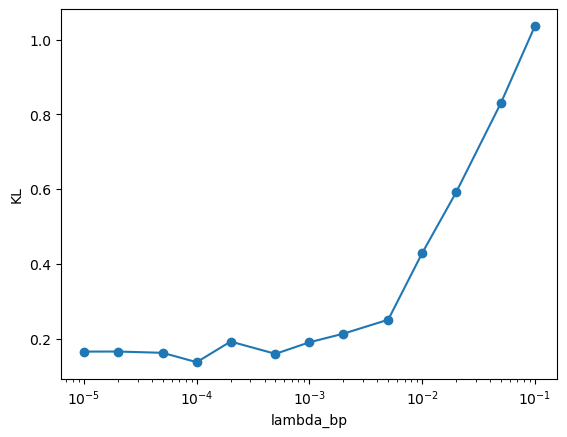

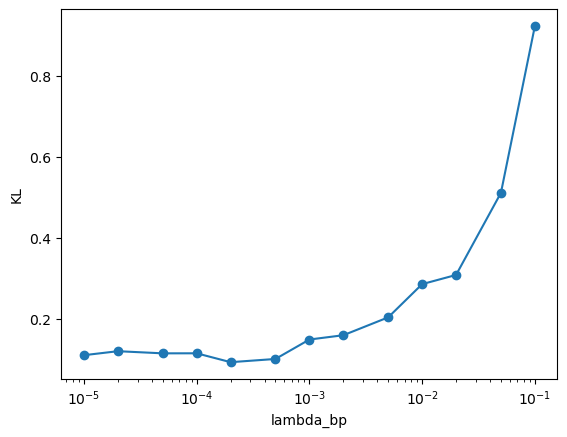

In [15]:
plot_results(results_graph, 'lambda_bp', 'KL')
plot_results(results_tree, 'lambda_bp', 'KL')

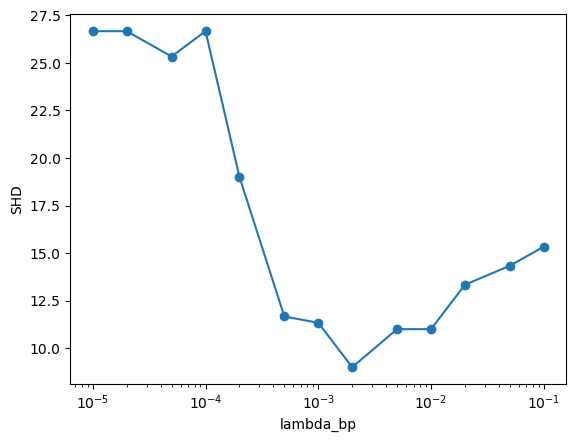

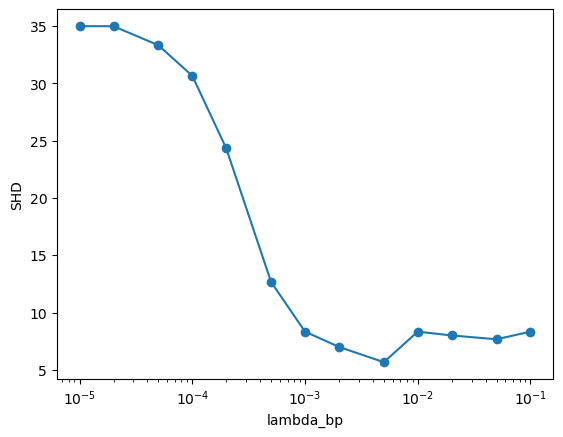

In [16]:
plot_results(results_graph, 'lambda_bp', 'SHD')
plot_results(results_tree, 'lambda_bp', 'SHD')

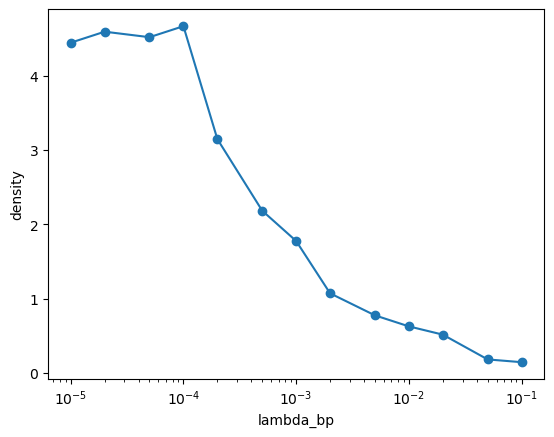

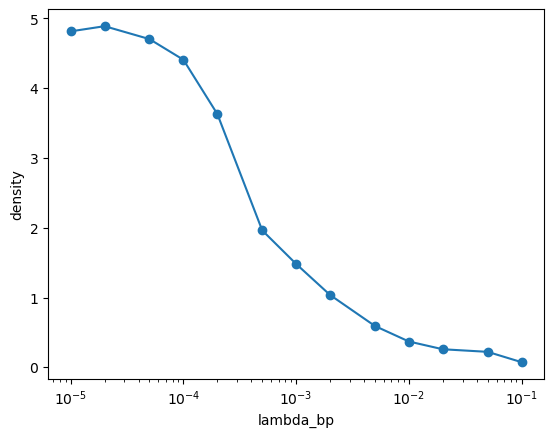

In [17]:
plot_results(results_graph, 'lambda_bp', 'density')
plot_results(results_tree, 'lambda_bp', 'density')

# Recovered Graphs

In [13]:
best_lrn_graph, ls_graph, dg_graph = one_learner(random_graph, samples_graph, K=10, max_factor_size=5, lr=0.01,
                                                 l_mask=0.0, l_weight=0, l_bp=0.001, seed=317, schedule=True)
best_lrn_tree, ls_tree, gd_tree = one_learner(random_tree, samples_tree, K=10, max_factor_size=5, lr=0.01,
                                              l_mask=0.0, l_weight=0, l_bp=0.001, seed=317, schedule=True)
 
# best_lrn_graph, ls_graph, dg_graph = one_learner(random_graph, samples_graph, K=15, max_factor_size=5, lr=0.01,
#                                                  l_mask=1e-4, l_weight=1e-4, l_bp=0.005, seed=317, schedule=True)
# best_lrn_tree, ls_tree, gd_tree = one_learner(random_tree, samples_tree, K=15, max_factor_size=5, lr=0.01,
#                                               l_mask=1e-4, l_weight=1e-4, l_bp=0.005, seed=317, schedule=True)

Epoch   50/100  loss=0.5731  main=0.5574  reg=0.0157
Epoch  100/100  loss=0.5290  main=0.5202  reg=0.0089
Epoch   50/100  loss=0.6250  main=0.5880  reg=0.0371
Epoch  100/100  loss=0.6290  main=0.6261  reg=0.0028


In [14]:
best_res_graph = {
    'n_active_factors' : best_lrn_graph.network.n_active_factors().item(),
    'avg_factor_size' : best_lrn_graph.network.avg_factor_size().item(),
    'density' : graph_density(best_lrn_graph),
    'SHD' : structural_hamming_distance(random_graph, best_lrn_graph),
    'KL' : kl_divergence(random_graph, best_lrn_graph)
}

best_res_tree = {
    'n_active_factors' : best_lrn_tree.network.n_active_factors().item(),
    'avg_factor_size' : best_lrn_tree.network.avg_factor_size().item(),
    'density' : graph_density(best_lrn_tree),
    'SHD' : structural_hamming_distance(random_tree, best_lrn_tree),
    'KL' : kl_divergence(random_tree, best_lrn_tree)
}

In [15]:
compare_graph(random_graph, best_lrn_graph)

=== GRAPH 1 FACTORS ===
[1, 2]
[0, 3, 7]
[1, 3, 5]
[2, 5]
[1, 5, 8]
[1, 5, 9]
[2, 6]
[2, 4, 8]

=== GRAPH 2 FACTORS ===
[8]
[2, 8]
[1, 3, 5, 9]
[2, 4, 8]
[1, 9]
[1, 8]
[6]
[0, 1, 7]
[1, 8]
[0, 1, 3, 5]


In [16]:
compare_graph(random_tree, best_lrn_tree)

=== GRAPH 1 FACTORS ===
[0, 1]
[0, 8]
[0, 2]
[2, 3]
[2, 4]
[4, 9]
[5, 8]
[6, 7]
[6, 8]

=== GRAPH 2 FACTORS ===
[2, 3, 8]
[2, 3]
[7]
[2, 8]
[5, 8]
[4, 9]
[6, 7]
[0, 1, 7]
[6, 8]
[0, 3]


In [17]:
kl_mle_optimal(random_graph, samples_graph)

0.37322691928488594

In [18]:
chow_liu_graph = chow_liu(samples_graph, alphabet_size=2)
chow_liu_res_graph = {
    'n_active_factors' : len(chow_liu_graph.factors),
    'avg_factor_size' : np.mean([len(sc) for sc, f in chow_liu_graph.factors]),
    'density' : graph_density(chow_liu_graph),
    'SHD' : structural_hamming_distance(random_graph, chow_liu_graph),
    'KL' : kl_divergence(random_graph, chow_liu_graph)
}

chow_liu_tree = chow_liu(samples_tree, alphabet_size=2)
chow_liu_res_tree = {
    'n_active_factors' : len(chow_liu_tree.factors),
    'avg_factor_size' : np.mean([len(sc) for sc, f in chow_liu_tree.factors]),
    'density' : graph_density(chow_liu_tree),
    'SHD' : structural_hamming_distance(random_tree, chow_liu_tree),
    'KL' : kl_divergence(random_tree, chow_liu_tree)
}

In [19]:
chow_liu_res_graph, best_res_graph

({'n_active_factors': 10,
  'avg_factor_size': 1.9,
  'density': 1.0,
  'SHD': 9,
  'KL': 0.13101763802609706},
 {'n_active_factors': 10,
  'avg_factor_size': 2.4000000953674316,
  'density': 1.6666666666666667,
  'SHD': 9,
  'KL': 0.11971037321575312})

In [20]:
chow_liu_res_tree, best_res_tree

({'n_active_factors': 10,
  'avg_factor_size': 1.9,
  'density': 1.0,
  'SHD': 0,
  'KL': 0.012789733215894338},
 {'n_active_factors': 10,
  'avg_factor_size': 2.0999999046325684,
  'density': 1.2222222222222223,
  'SHD': 8,
  'KL': 0.09941949051791303})

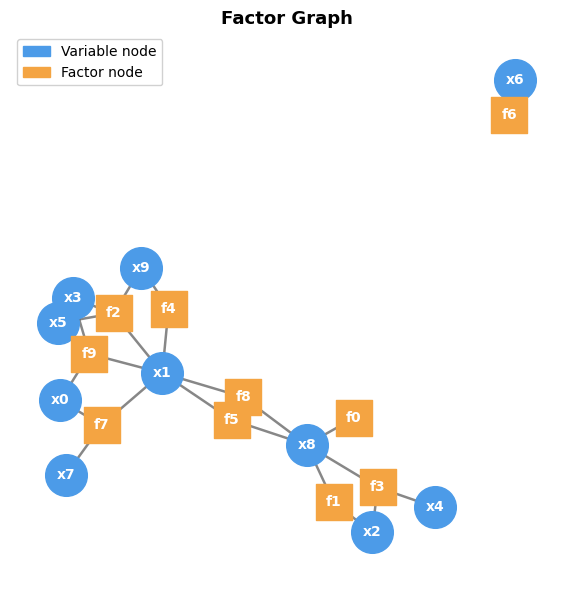

In [21]:
# def learner_to_graph(lrn):
#     fscopes = lrn.extract_graph()['factor_scopes']
#     def h(): return 1
#     factors = [(f, h) for f in fscopes.values()]
#     g = TrueGraph(n=lrn.network.n_vars, factors=factors)
#     return g

learner_to_graph(best_lrn_graph).display_graph(seed=38)
plt.show()

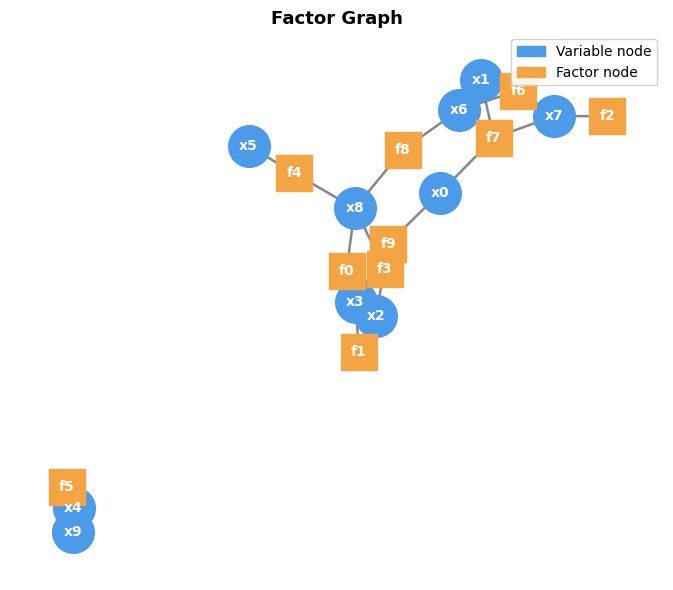

In [22]:
learner_to_graph(best_lrn_tree).display_graph(seed=34)
plt.show()

In [23]:
kl_mle_optimal(random_tree, samples_tree)

0.40577652351832594

# Reg vs Sample Size

In [24]:
mega_samples_graph = random_graph.sample(nsamples=5000, seed=689)

100%|██████████████████████████████████████| 5000/5000 [00:13<00:00, 372.95it/s]


In [25]:
sample_sizes = [100,500,1000,5000]
ss_results = {}

# ss_lambda_bp_vals = 10**np.arange(-5,-2+0.01,0.25)

for ss in sample_sizes:
    samples_here = mega_samples_graph[:ss,]
    exp_results = run_experiment(
        random_graph, samples_here, lambda_bp_vals,
        max_factor_size=5, epochs=100, seed=317, n_runs=1
    )
    ss_results[ss] = exp_results

100%|███████████████████████████████████████████| 13/13 [06:11<00:00, 28.56s/it]


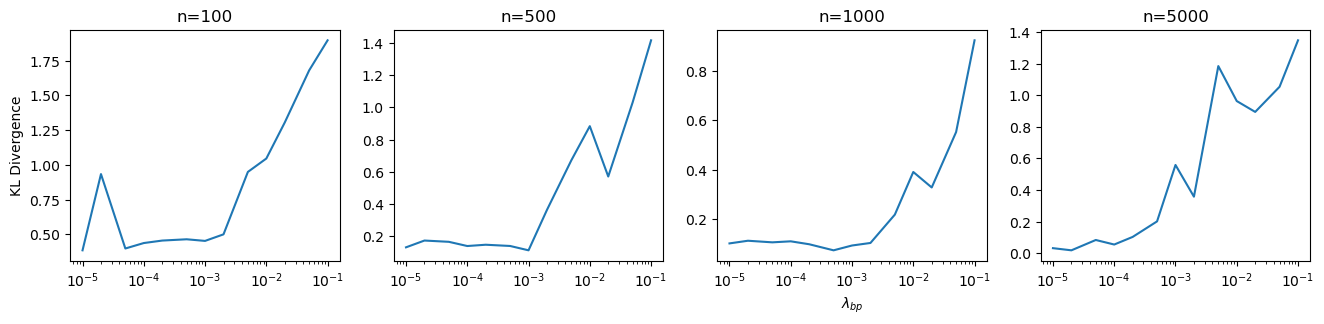

In [42]:
# KL plot
fig, axs = plt.subplots(1,4, figsize=(16,3))
for i in range(len(sample_sizes)):
    ss = sample_sizes[i]
    res = ss_results[ss]
    x = [rs['lambda_bp'] for rs in res]
    y = [rs['KL'] for rs in res]
    axs[i].plot(x, y)
    axs[i].set_xscale("log")
    axs[i].set_title(f"n={ss}")
    if i == 0:
        axs[i].set_ylabel("KL Divergence")
    if i == 2:
        axs[i].set_xlabel("$\lambda_{bp}$")
plt.show()

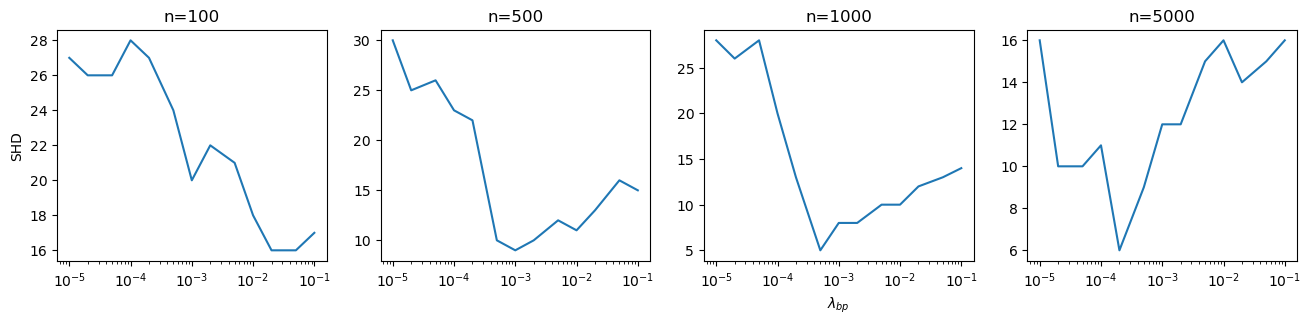

In [43]:
# SHD plot
fig, axs = plt.subplots(1,4, figsize=(16,3))
for i in range(len(sample_sizes)):
    ss = sample_sizes[i]
    res = ss_results[ss]
    x = [rs['lambda_bp'] for rs in res]
    y = [rs['SHD'] for rs in res]
    axs[i].plot(x, y)
    axs[i].set_xscale("log")
    axs[i].set_title(f"n={ss}")
    if i == 0:
        axs[i].set_ylabel("SHD")
    if i == 2:
        axs[i].set_xlabel("$\lambda_{bp}$")
plt.show()

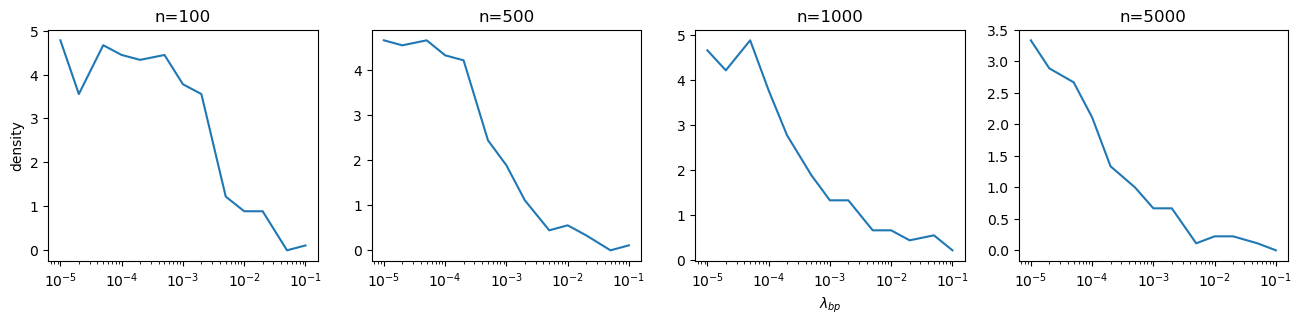

In [44]:
# density plot
fig, axs = plt.subplots(1,4, figsize=(16,3))
for i in range(len(sample_sizes)):
    ss = sample_sizes[i]
    res = ss_results[ss]
    x = [rs['lambda_bp'] for rs in res]
    y = [rs['density'] for rs in res]
    axs[i].plot(x, y)
    axs[i].set_xscale("log")
    axs[i].set_title(f"n={ss}")
    if i == 0:
        axs[i].set_ylabel("density")
    if i == 2:
        axs[i].set_xlabel("$\lambda_{bp}$")
plt.show()

# Reg vs Graph Size

In [29]:
n_vars_list = np.arange(5,31,5,dtype=np.int32)

size_results = {}

# size_lambda_bp_vals = 10**np.arange(-4,-2+0.01,0.25)

for size in n_vars_list:
    rng = np.random.default_rng(123)
    graph_here = generate_random_tree(n=size, alphabet_size=2, rng=rng)
    samples_here = graph_here.sample(nsamples=500, seed=50, progress=False)
    exp_results = run_experiment(
        graph_here, samples_here, lambda_bp_vals,
        max_factor_size=5, epochs=100, seed=317, compute_kl=False, n_runs=1
    )
    size_results[size] = exp_results

100%|███████████████████████████████████████████| 13/13 [01:40<00:00,  7.72s/it]


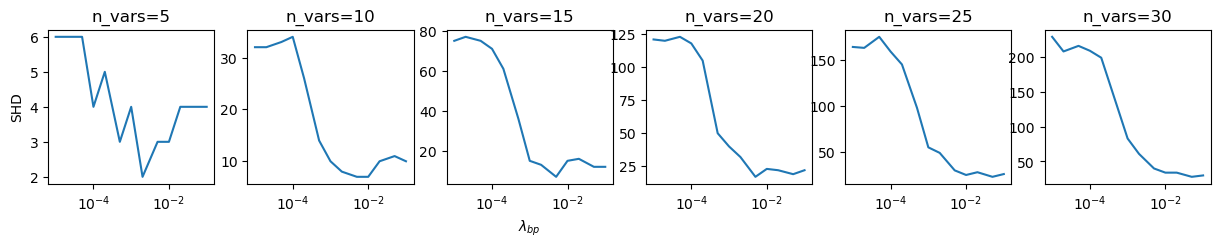

In [45]:
# SHD plot
fig, axs = plt.subplots(1,6, figsize=(15,2))
for i in range(len(n_vars_list)):
    nv = n_vars_list[i]
    res = size_results[nv]
    x = [rs['lambda_bp'] for rs in res]
    y = [rs['SHD'] for rs in res]
    axs[i].plot(x, y)
    axs[i].set_xscale("log")
    axs[i].set_title(f"n_vars={nv}")
    if i == 0:
        axs[i].set_ylabel("SHD")
    if i == 2:
        axs[i].set_xlabel("$\lambda_{bp}$")
plt.show()

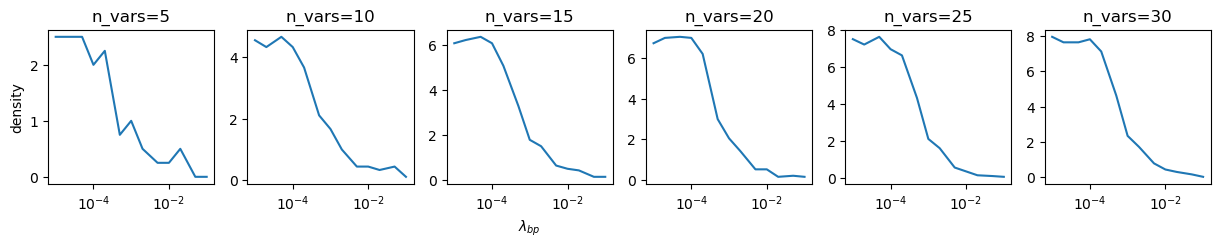

In [46]:
# density plot
fig, axs = plt.subplots(1,6, figsize=(15,2))
for i in range(len(n_vars_list)):
    nv = n_vars_list[i]
    res = size_results[nv]
    x = [rs['lambda_bp'] for rs in res]
    y = [rs['density'] for rs in res]
    axs[i].plot(x, y)
    axs[i].set_xscale("log")
    axs[i].set_title(f"n_vars={nv}")
    if i == 0:
        axs[i].set_ylabel("density")
    if i == 2:
        axs[i].set_xlabel("$\lambda_{bp}$")
plt.show()

# Final Visualizations

In [32]:
mle_kl_graph = kl_mle_optimal(random_graph, samples_graph)
mle_kl_tree = kl_mle_optimal(random_tree, samples_tree)

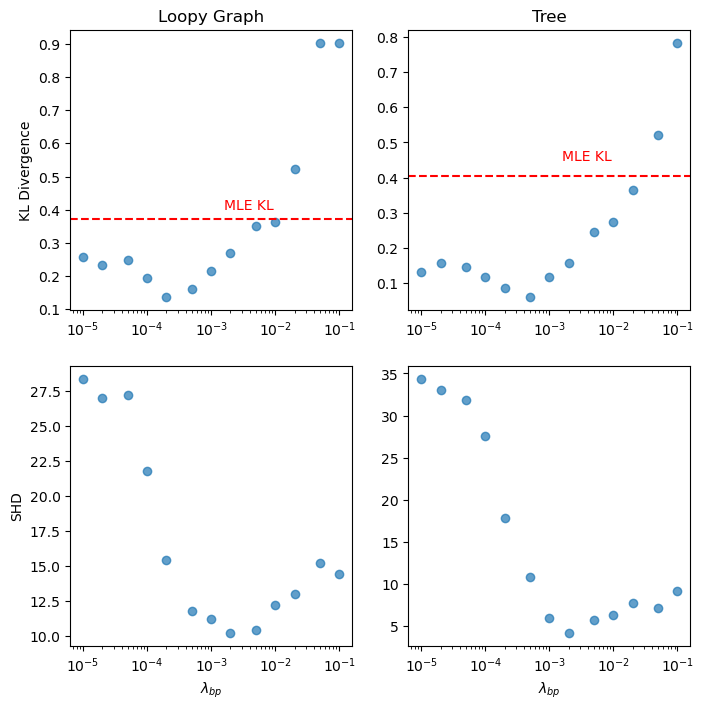

In [48]:
fig, axs = plt.subplots(2,2, figsize=(8,8))

x_gr = [r['lambda_bp'] for r in results_graph]
x_tr = [r['lambda_bp'] for r in results_tree]
y_gr_kl = [r['KL'] for r in results_graph]
y_gr_shd = [r['SHD'] for r in results_graph]
y_tr_kl = [r['KL'] for r in results_tree]
y_tr_shd = [r['SHD'] for r in results_tree]

axs[0,0].scatter(x_gr, y_gr_kl, alpha=0.7)
axs[0,0].axhline(y=mle_kl_graph, color='r', linestyle='--')
axs[0,0].annotate("MLE KL", (10**-2.8,0.4), color='r')
axs[0,0].set_xscale('log')
axs[0,0].set_ylabel("KL Divergence")
axs[0,0].set_title("Loopy Graph")

axs[0,1].scatter(x_tr, y_tr_kl, alpha=0.7)
axs[0,1].axhline(y=mle_kl_tree, color='r', linestyle='--')
axs[0,1].annotate("MLE KL", (10**-2.8,0.45), color='r')
axs[0,1].set_xscale('log')
axs[0,1].set_title("Tree")

axs[1,0].scatter(x_gr, y_gr_shd, alpha=0.7)
axs[1,0].set_xscale('log')
axs[1,0].set_ylabel("SHD")
axs[1,0].set_xlabel("$\lambda_{bp}$")

axs[1,1].scatter(x_tr, y_tr_shd, alpha=0.7)
axs[1,1].set_xscale('log')
axs[1,1].set_xlabel("$\lambda_{bp}$")

# plt.savefig('../img/reg_fig.png')
plt.show()

In [35]:
lrn_high_reg, _, _ = one_learner(random_graph, samples_graph, K=10, l_bp=0.01, seed=317)
lrn_low_reg, _, _ = one_learner(random_graph, samples_graph, K=10, l_bp=0.0001, seed=317)

Epoch   50/100  loss=0.6719  main=0.6540  reg=0.0178
Epoch  100/100  loss=0.6126  main=0.6121  reg=0.0004
Epoch   50/100  loss=0.5617  main=0.5481  reg=0.0137
Epoch  100/100  loss=0.5083  main=0.4986  reg=0.0096


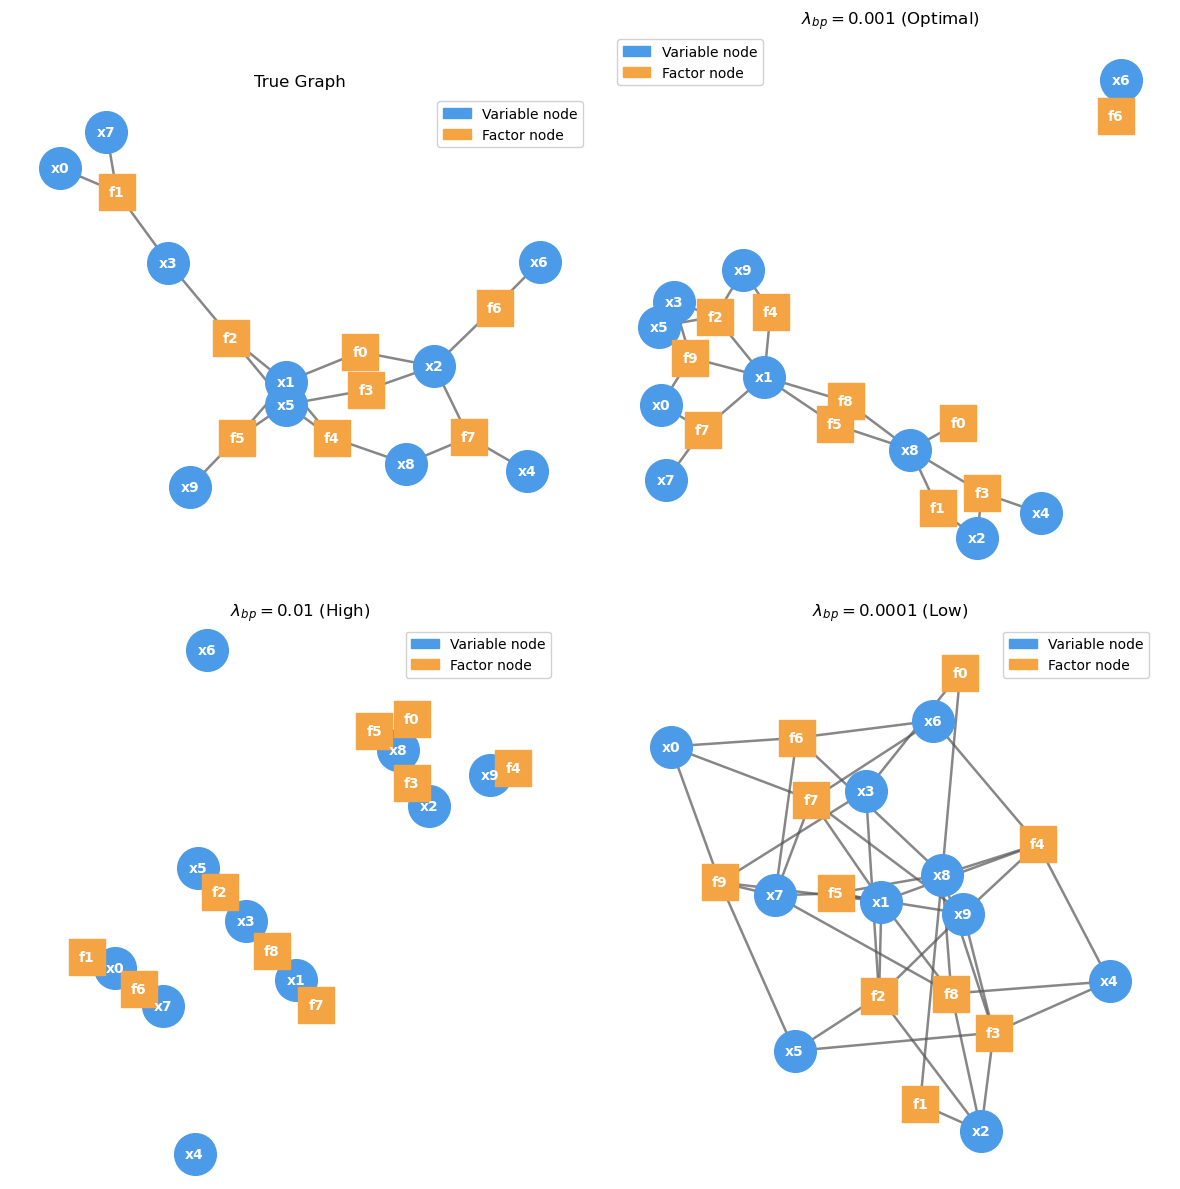

In [36]:
fig, axs = plt.subplots(2,2, figsize=(12,12))

random_graph.display_graph(seed=388, ax=axs[0,0])
learner_to_graph(best_lrn_graph).display_graph(seed=38, ax=axs[0,1])
learner_to_graph(lrn_high_reg).display_graph(seed=38, ax=axs[1,0])
learner_to_graph(lrn_low_reg).display_graph(seed=38, ax=axs[1,1])

axs[0,0].set_title("True Graph")
axs[0,1].set_title("$\lambda_{bp}=0.001$ (Optimal)")
axs[1,0].set_title("$\lambda_{bp}=0.01$ (High)")
axs[1,1].set_title("$\lambda_{bp}=0.0001$ (Low)")

plt.tight_layout()
plt.show()

In [37]:
print(f"KL MLE: {kl_mle_optimal(random_graph, samples_graph):.4f}")
print(f"KL Best Reg: {kl_divergence(random_graph, best_lrn_graph):.4f}")
print(f"KL High Reg: {kl_divergence(random_graph, lrn_high_reg):.4f}")
print(f"KL Low Reg: {kl_divergence(random_graph, lrn_low_reg):.4f}")

print(f"SHD Best Reg: {structural_hamming_distance(random_graph, best_lrn_graph):.0f}")
print(f"SHD High Reg: {structural_hamming_distance(random_graph, lrn_high_reg):.0f}")
print(f"SHD Low Reg: {structural_hamming_distance(random_graph, lrn_low_reg):.0f}")

print(f"Density Best Reg: {graph_density(best_lrn_graph):.2f}")
print(f"Density High Reg: {graph_density(lrn_high_reg):.2f}")
print(f"Density Low Reg: {graph_density(lrn_low_reg):.2f}")

KL MLE: 0.3732
KL Best Reg: 0.1197
KL High Reg: 0.4712
KL Low Reg: 0.1225
SHD Best Reg: 9
SHD High Reg: 12
SHD Low Reg: 25
Density Best Reg: 1.67
Density High Reg: 0.44
Density Low Reg: 4.33


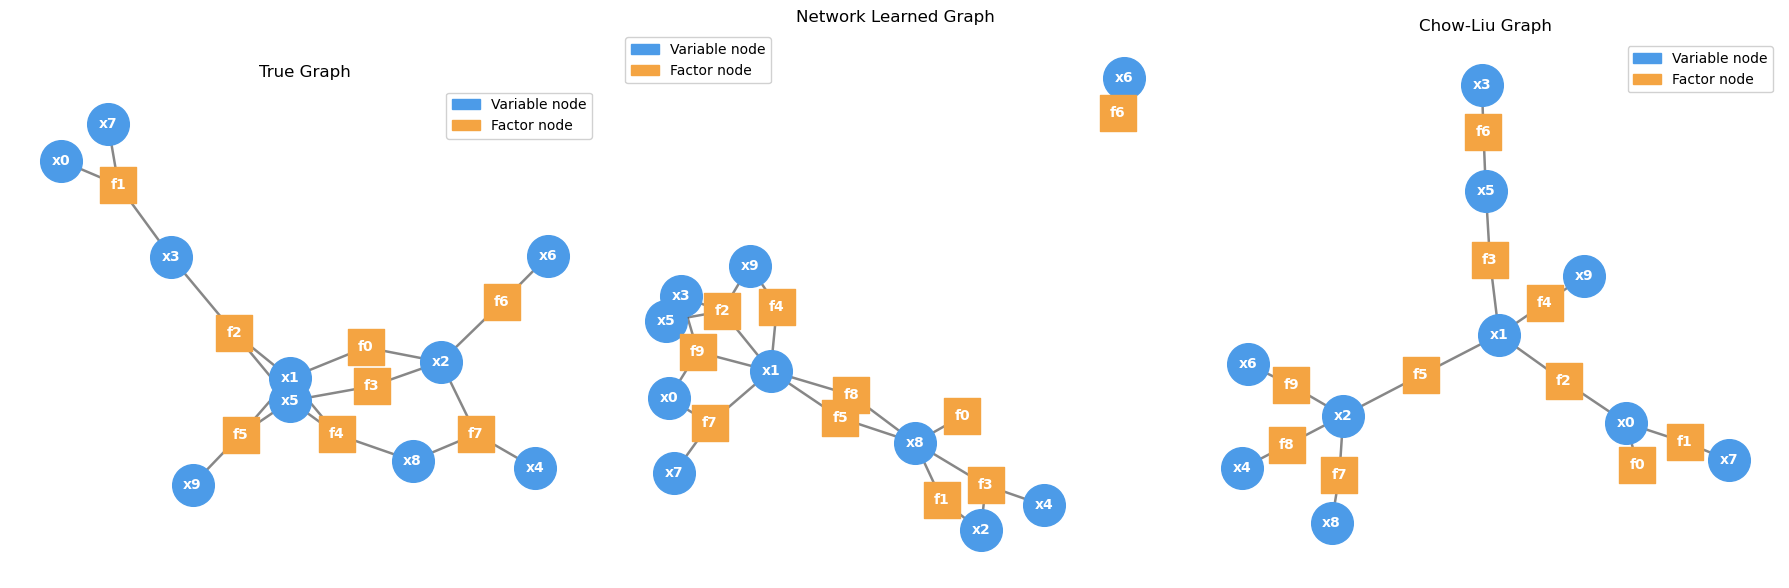

In [49]:
# Initial comparison to Chow-Liu

fig, axs = plt.subplots(1,3, figsize=(18,6))

random_graph.display_graph(seed=388, ax=axs[0])
learner_to_graph(best_lrn_graph).display_graph(seed=38, ax=axs[1])
chow_liu_graph.display_graph(seed=10, ax=axs[2])

axs[0].set_title("True Graph")
axs[1].set_title("Network Learned Graph")
axs[2].set_title("Chow-Liu Graph")

plt.show()

In [39]:
print(f"KL MLE: {kl_mle_optimal(random_graph, samples_graph):.4f}")
print(f"KL Network: {kl_divergence(random_graph, best_lrn_graph):.4f}")
print(f"KL Chow-Liu: {kl_divergence(random_graph, chow_liu_graph):.4f}")

KL MLE: 0.3732
KL Network: 0.1197
KL Chow-Liu: 0.1310


In [40]:
print(f"SHD Network: {structural_hamming_distance(random_graph, best_lrn_graph):.0f}")
print(f"SHD Chow-Liu: {structural_hamming_distance(random_graph, chow_liu_graph):.0f}")

SHD Network: 9
SHD Chow-Liu: 9


In [41]:
print(f"Density Graph: {graph_density(random_graph):.2f}")
print(f"Density Network: {graph_density(best_lrn_graph):.2f}")
print(f"Density Chow-Liu: {graph_density(chow_liu_graph):.2f}")

Density Graph: 1.78
Density Network: 1.67
Density Chow-Liu: 1.00
